   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


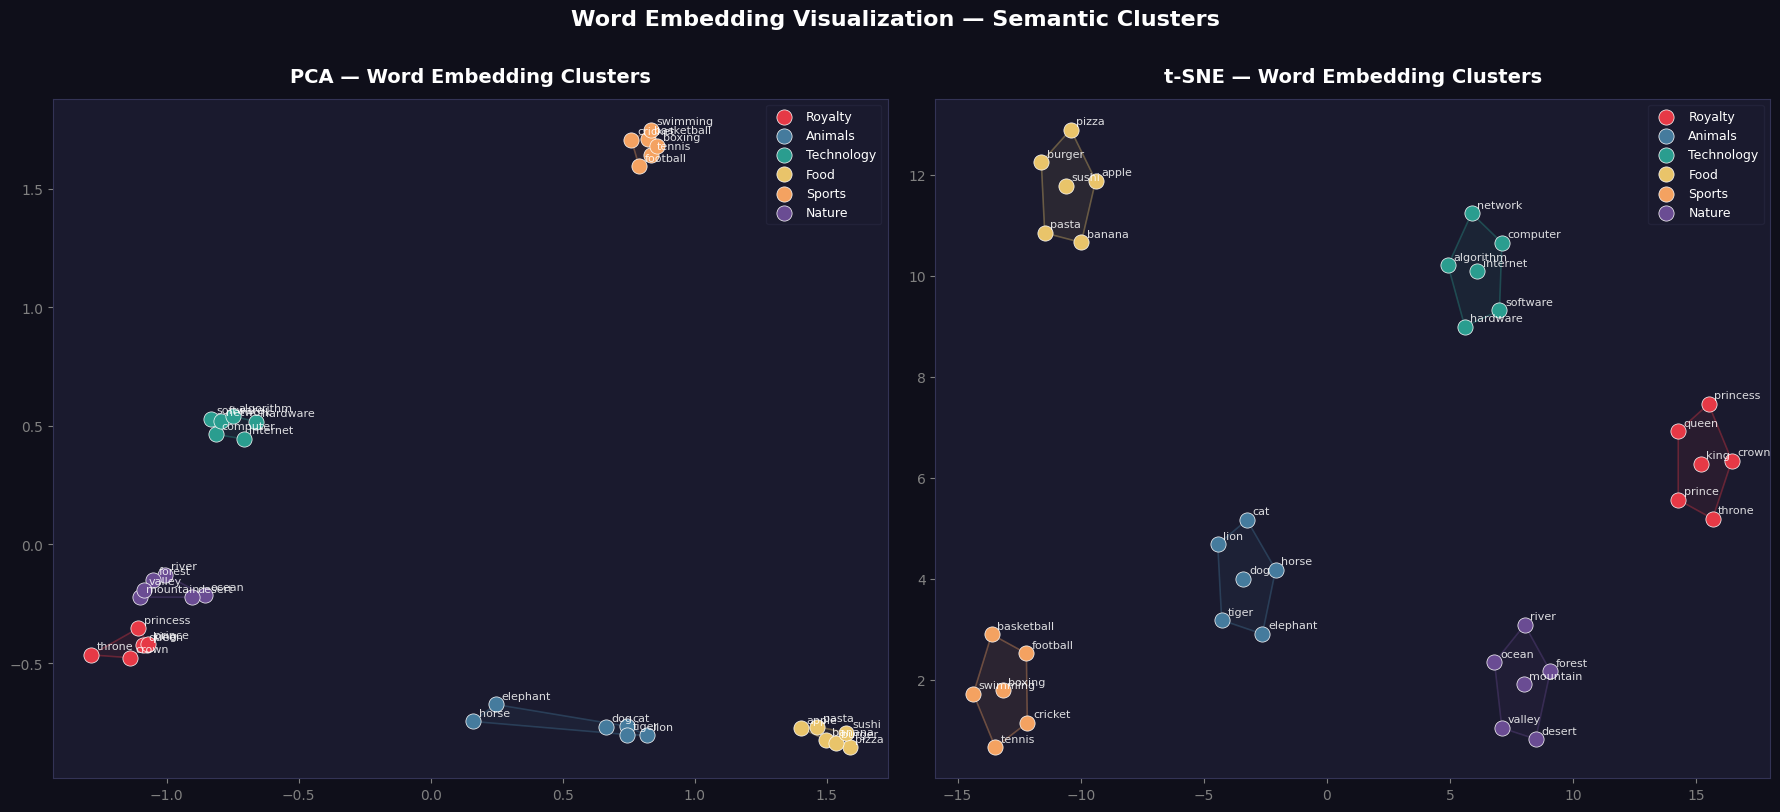


PCA explained variance ratio: [0.279 0.204]
Total variance explained:      0.483


In [1]:
!pip install transformers gensim -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from gensim.models import Word2Vec

# Sample vocabulary with semantic groups
word_groups = {
    'Royalty':    ['king', 'queen', 'prince', 'princess', 'throne', 'crown'],
    'Animals':    ['dog', 'cat', 'lion', 'tiger', 'elephant', 'horse'],
    'Technology': ['computer', 'internet', 'software', 'hardware', 'network', 'algorithm'],
    'Food':       ['apple', 'banana', 'pizza', 'burger', 'sushi', 'pasta'],
    'Sports':     ['football', 'cricket', 'tennis', 'basketball', 'swimming', 'boxing'],
    'Nature':     ['river', 'mountain', 'forest', 'ocean', 'desert', 'valley']
}

# Training corpus
corpus = [
    "the king and queen rule the kingdom from the throne wearing a crown",
    "the prince and princess live in the palace near the throne",
    "a dog and cat are common pets while lion and tiger are wild animals",
    "the elephant and horse are large animals found in nature",
    "the computer runs software and hardware connected through a network and internet",
    "the algorithm processes data on the computer through software and network",
    "apple and banana are fruits while pizza burger sushi and pasta are meals",
    "football cricket tennis basketball swimming and boxing are popular sports",
    "the river flows through the forest near the mountain and valley",
    "the ocean surrounds the desert and mountain creating a natural valley",
    "king queen prince princess throne crown palace royal kingdom",
    "dog cat lion tiger elephant horse animal wild domestic",
    "computer internet software hardware network algorithm data digital",
    "apple banana pizza burger sushi pasta food meal eat",
    "football cricket tennis basketball swimming boxing sport athlete",
    "river mountain forest ocean desert valley nature landscape"
]

tokenized_corpus = [sent.lower().split() for sent in corpus]

# Train Word2Vec
model = Word2Vec(tokenized_corpus, vector_size=100, window=5,
                 min_count=1, workers=4, epochs=500, sg=1)

# Collect words and embeddings
all_words, all_vectors, all_labels, all_colors = [], [], [], []
colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#6A4C93']

for (group, words), color in zip(word_groups.items(), colors):
    for word in words:
        if word in model.wv:
            all_words.append(word)
            all_vectors.append(model.wv[word])
            all_labels.append(group)
            all_colors.append(color)

vectors = np.array(all_vectors)

# PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(vectors)

# t-SNE
tsne = TSNE(n_components=2, perplexity=10, random_state=42,
            n_iter=2000, learning_rate='auto', init='pca')
tsne_result = tsne.fit_transform(vectors)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0F0F1A')

for ax, result, title in zip(axes,
                              [pca_result, tsne_result],
                              ['PCA — Word Embedding Clusters',
                               't-SNE — Word Embedding Clusters']):
    ax.set_facecolor('#1A1A2E')

    # Draw convex hulls per group
    from scipy.spatial import ConvexHull
    unique_groups = list(word_groups.keys())
    for group, color in zip(unique_groups, colors):
        idx = [i for i, l in enumerate(all_labels) if l == group]
        pts = result[idx]
        ax.scatter(pts[:, 0], pts[:, 1], c=color, s=120,
                   edgecolors='white', linewidths=0.5,
                   label=group, zorder=3)
        for i, word in enumerate([all_words[j] for j in idx]):
            ax.annotate(word, (pts[i, 0], pts[i, 1]),
                        fontsize=8, color='white', alpha=0.85,
                        xytext=(4, 4), textcoords='offset points')
        if len(pts) >= 3:
            try:
                hull = ConvexHull(pts)
                hull_pts = np.append(hull.vertices, hull.vertices[0])
                ax.fill(pts[hull_pts, 0], pts[hull_pts, 1],
                        alpha=0.08, color=color)
                ax.plot(pts[hull_pts, 0], pts[hull_pts, 1],
                        color=color, alpha=0.3, linewidth=1.2)
            except Exception:
                pass

    ax.set_title(title, fontsize=14, fontweight='bold',
                 color='white', pad=12)
    ax.tick_params(colors='gray')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')
    legend = ax.legend(loc='upper right', framealpha=0.2,
                       labelcolor='white', fontsize=9,
                       facecolor='#1A1A2E', edgecolor='#444466')

plt.suptitle("Word Embedding Visualization — Semantic Clusters",
             fontsize=16, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig('word_embeddings.png', dpi=150, bbox_inches='tight',
            facecolor='#0F0F1A')
plt.show()

print("\nPCA explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Total variance explained:     ", pca.explained_variance_ratio_.sum().round(3))